Device: cuda
Vocabulary size : 90
Total tokens    : 111
Training samples: 106
Model parameters: 248,794
Epoch [ 10/80]  Loss: 4.2888
Epoch [ 20/80]  Loss: 2.8697
Epoch [ 30/80]  Loss: 1.9898
Epoch [ 40/80]  Loss: 1.5514
Epoch [ 50/80]  Loss: 1.3172
Epoch [ 60/80]  Loss: 1.2093
Epoch [ 70/80]  Loss: 1.1659
Epoch [ 80/80]  Loss: 1.0658


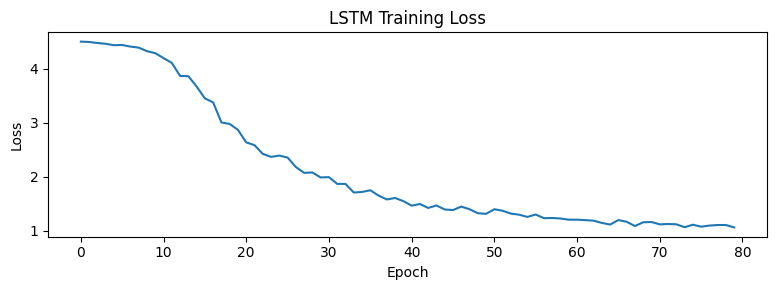


LSTM GENERATED SEQUENCES

Seed : machine learning models learn patterns
Output: machine learning models learn patterns forecasting sequence sequence generation widely step used in

Seed : lstm uses gates to control
Output: lstm uses gates to control useful gru gru models maintain artificial lstm architecture.

Seed : deep learning improves sequence modeling
Output: deep learning improves sequence modeling performance. performance. performance. in time recognition step. sequences.

Seed : generative models learn probability distributions
Output: generative models learn probability distributions they generate new samples to to training sequence


In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import random
import matplotlib.pyplot as plt
from IPython.display import clear_output

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# =========================
# 1. Dataset
# =========================
corpus = """
machine learning models learn patterns from data.
sequence models process data step by step.
recurrent neural networks are designed for sequential tasks.
rnn models maintain hidden states across time steps.
long short term memory networks solve long dependency problems.
lstm uses gates to control information flow.
gru models simplify the lstm architecture.
sequence prediction is useful in many applications.
language modeling predicts the next word in a sentence.
speech recognition processes audio sequences.
time series forecasting predicts future values.
music generation creates new melodies.
generative models learn probability distributions.
they generate new samples similar to training data.
sequence generation is widely used in artificial intelligence.
deep learning improves sequence modeling performance.
""".strip()

# =========================
# 2. Preprocessing
# =========================
# Tokenise at word level
words  = corpus.lower().split()
vocab  = sorted(set(words))
vocab  = ["<PAD>", "<UNK>"] + vocab   # reserve special tokens

word2idx = {w: i for i, w in enumerate(vocab)}
idx2word = {i: w for w, i in word2idx.items()}
vocab_size = len(vocab)

print(f"Vocabulary size : {vocab_size}")
print(f"Total tokens    : {len(words)}")

# =========================
# 3. Sequence Pairs
# =========================
SEQ_LEN = 5   # input window length

def build_sequences(words, seq_len):
    X, y = [], []
    indices = [word2idx[w] for w in words]
    for i in range(len(indices) - seq_len):
        X.append(indices[i : i + seq_len])
        y.append(indices[i + seq_len])
    return torch.tensor(X, dtype=torch.long), torch.tensor(y, dtype=torch.long)

X, y = build_sequences(words, SEQ_LEN)
print(f"Training samples: {len(X)}")

dataset    = torch.utils.data.TensorDataset(X, y)
dataloader = torch.utils.data.DataLoader(dataset, batch_size=32, shuffle=True)

# =========================
# 4. LSTM Model
# =========================
class LSTMGenerator(nn.Module):
    def __init__(self, vocab_size, embed_dim=64, hidden_dim=128, num_layers=2, dropout=0.3):
        super().__init__()
        self.embedding  = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm       = nn.LSTM(embed_dim, hidden_dim, num_layers,
                                  batch_first=True, dropout=dropout)
        self.dropout    = nn.Dropout(dropout)
        self.fc         = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x, hidden=None):
        emb = self.dropout(self.embedding(x))          # (B, T, E)
        out, hidden = self.lstm(emb, hidden)            # (B, T, H)
        logits = self.fc(self.dropout(out[:, -1, :]))  # use last timestep
        return logits, hidden

    def init_hidden(self, batch_size):
        h = torch.zeros(2, batch_size, 128).to(device)
        c = torch.zeros(2, batch_size, 128).to(device)
        return (h, c)

model = LSTMGenerator(vocab_size).to(device)
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

# =========================
# 5. Training
# =========================
criterion  = nn.CrossEntropyLoss()
optimizer  = optim.Adam(model.parameters(), lr=0.001)
scheduler  = optim.lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.5)

EPOCHS = 80
losses = []

for epoch in range(1, EPOCHS + 1):
    model.train()
    epoch_loss = 0

    for xb, yb in dataloader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        logits, _ = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        epoch_loss += loss.item()

    scheduler.step()
    avg_loss = epoch_loss / len(dataloader)
    losses.append(avg_loss)

    if epoch % 10 == 0:
        print(f"Epoch [{epoch:3d}/{EPOCHS}]  Loss: {avg_loss:.4f}")

# Plot training loss
plt.figure(figsize=(8, 3))
plt.plot(losses)
plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.title("LSTM Training Loss")
plt.tight_layout(); plt.show()

# =========================
# 6. Sequence Generation
# =========================
def generate_sequence(seed_words, num_words=10, temperature=1.0):
    """
    seed_words : list of words to prime the model
    num_words  : how many new words to generate
    temperature: >1 = more random, <1 = more deterministic
    """
    model.eval()
    # Map seed to indices; fall back to <UNK> for OOV words
    indices = [word2idx.get(w.lower(), word2idx["<UNK>"]) for w in seed_words]
    # Keep only the last SEQ_LEN tokens
    indices = indices[-SEQ_LEN:]

    generated = list(seed_words)

    with torch.no_grad():
        for _ in range(num_words):
            inp = torch.tensor([indices[-SEQ_LEN:]], dtype=torch.long).to(device)
            logits, _ = model(inp)
            # Apply temperature scaling
            probs = torch.softmax(logits[0] / temperature, dim=0).cpu().numpy()
            next_idx = np.random.choice(len(probs), p=probs)
            next_word = idx2word[next_idx]
            generated.append(next_word)
            indices.append(next_idx)

    return " ".join(generated)

# --- Generate samples ---
print("\n" + "="*60)
print("LSTM GENERATED SEQUENCES")
print("="*60)

seeds = [
    ["machine", "learning", "models", "learn", "patterns"],
    ["lstm", "uses", "gates", "to", "control"],
    ["deep", "learning", "improves", "sequence", "modeling"],
    ["generative", "models", "learn", "probability", "distributions"],
]

for seed in seeds:
    seq = generate_sequence(seed, num_words=8, temperature=0.8)
    print(f"\nSeed : {' '.join(seed)}")
    print(f"Output: {seq}")

Device: cuda
Vocabulary size : 90
Training samples: 106
Transformer parameters: 288,090
Epoch [ 10/80]  Loss: 1.1973
Epoch [ 20/80]  Loss: 0.1506
Epoch [ 30/80]  Loss: 0.0413
Epoch [ 40/80]  Loss: 0.0257
Epoch [ 50/80]  Loss: 0.0200
Epoch [ 60/80]  Loss: 0.0171
Epoch [ 70/80]  Loss: 0.0204
Epoch [ 80/80]  Loss: 0.0165


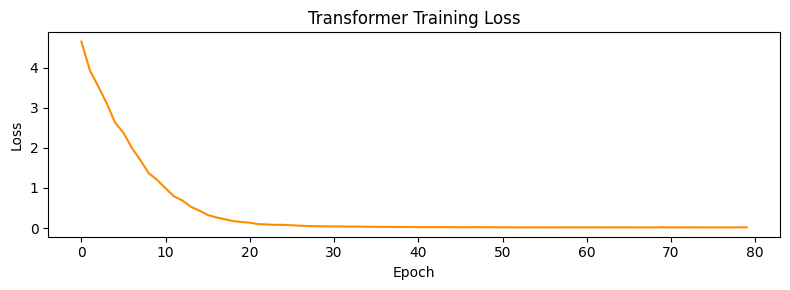


TRANSFORMER GENERATED SEQUENCES

Seed : machine learning models learn patterns
Output: machine learning models learn patterns from data. sequence models process data step by

Seed : lstm uses gates to control
Output: lstm uses gates to control information flow. gru models simplify the lstm architecture.

Seed : deep learning improves sequence modeling
Output: deep learning improves sequence modeling performance. sequences. time steps. speech recognition processes audio

Seed : generative models learn probability distributions
Output: generative models learn probability distributions widely used in artificial intelligence. deep learning improves

Positional Encoding Heatmap (first 20 positions, 32 dims)


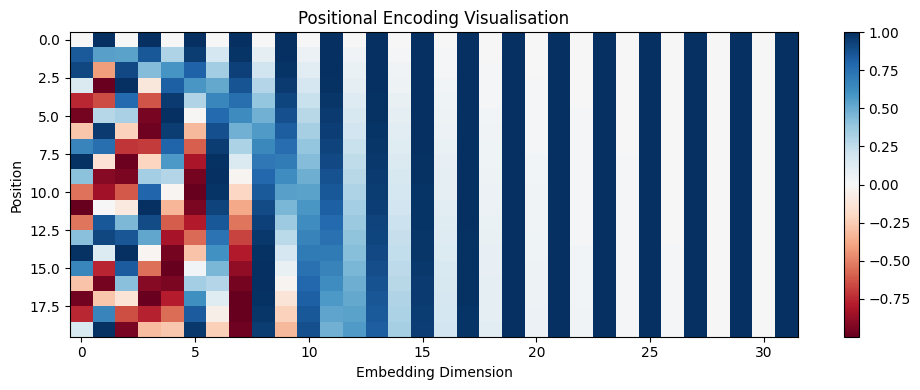

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import math
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# =========================
# 1. Dataset  (same corpus as Component I)
# =========================
corpus = """
machine learning models learn patterns from data.
sequence models process data step by step.
recurrent neural networks are designed for sequential tasks.
rnn models maintain hidden states across time steps.
long short term memory networks solve long dependency problems.
lstm uses gates to control information flow.
gru models simplify the lstm architecture.
sequence prediction is useful in many applications.
language modeling predicts the next word in a sentence.
speech recognition processes audio sequences.
time series forecasting predicts future values.
music generation creates new melodies.
generative models learn probability distributions.
they generate new samples similar to training data.
sequence generation is widely used in artificial intelligence.
deep learning improves sequence modeling performance.
""".strip()

# =========================
# 2. Preprocessing
# =========================
words    = corpus.lower().split()
vocab    = sorted(set(words))
vocab    = ["<PAD>", "<UNK>"] + vocab
word2idx = {w: i for i, w in enumerate(vocab)}
idx2word = {i: w for w, i in word2idx.items()}
vocab_size = len(vocab)
print(f"Vocabulary size : {vocab_size}")

# =========================
# 3. Sequence Pairs
# =========================
SEQ_LEN = 5

def build_sequences(words, seq_len):
    indices = [word2idx[w] for w in words]
    X, y = [], []
    for i in range(len(indices) - seq_len):
        X.append(indices[i : i + seq_len])
        y.append(indices[i + seq_len])
    return torch.tensor(X, dtype=torch.long), torch.tensor(y, dtype=torch.long)

X, y   = build_sequences(words, SEQ_LEN)
dataset    = torch.utils.data.TensorDataset(X, y)
dataloader = torch.utils.data.DataLoader(dataset, batch_size=32, shuffle=True)
print(f"Training samples: {len(X)}")

# =========================
# 4. Positional Encoding
# =========================
class PositionalEncoding(nn.Module):
    """
    Injects position information into embeddings using sine / cosine functions.
    PE(pos, 2i)   = sin(pos / 10000^(2i/d_model))
    PE(pos, 2i+1) = cos(pos / 10000^(2i/d_model))
    """
    def __init__(self, d_model, max_len=512, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)

        pe = torch.zeros(max_len, d_model)                       # (T, D)
        position = torch.arange(0, max_len).unsqueeze(1).float() # (T, 1)
        div_term = torch.exp(
            torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)                                      # (1, T, D)
        self.register_buffer("pe", pe)

    def forward(self, x):
        # x: (B, T, D)
        x = x + self.pe[:, :x.size(1), :]
        return self.dropout(x)

# =========================
# 5. Transformer Model
# =========================
class TransformerGenerator(nn.Module):
    def __init__(self, vocab_size, d_model=128, nhead=4,
                 num_layers=2, dim_feedforward=256, dropout=0.1):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model, padding_idx=0)
        self.pos_enc   = PositionalEncoding(d_model, dropout=dropout)

        encoder_layer  = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True       # (B, T, D) convention
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.fc_out      = nn.Linear(d_model, vocab_size)
        self.d_model     = d_model

    def forward(self, x):
        # x: (B, T)
        src_key_padding_mask = (x == 0)   # mask <PAD> tokens
        emb = self.embedding(x) * math.sqrt(self.d_model)   # scale embeddings
        emb = self.pos_enc(emb)                               # add positional info
        out = self.transformer(emb, src_key_padding_mask=src_key_padding_mask)
        # Predict from the last position
        logits = self.fc_out(out[:, -1, :])
        return logits

model = TransformerGenerator(vocab_size).to(device)
print(f"Transformer parameters: {sum(p.numel() for p in model.parameters()):,}")

# =========================
# 6. Training
# =========================
criterion = nn.CrossEntropyLoss(ignore_index=0)
optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=80)

EPOCHS = 80
losses = []

for epoch in range(1, EPOCHS + 1):
    model.train()
    epoch_loss = 0

    for xb, yb in dataloader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        logits = model(xb)
        loss   = criterion(logits, yb)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        epoch_loss += loss.item()

    scheduler.step()
    avg_loss = epoch_loss / len(dataloader)
    losses.append(avg_loss)

    if epoch % 10 == 0:
        print(f"Epoch [{epoch:3d}/{EPOCHS}]  Loss: {avg_loss:.4f}")

# Plot training loss
plt.figure(figsize=(8, 3))
plt.plot(losses, color="darkorange")
plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.title("Transformer Training Loss")
plt.tight_layout(); plt.show()

# =========================
# 7. Sequence Generation
# =========================
def generate_sequence_transformer(seed_words, num_words=10, temperature=0.9):
    model.eval()
    indices = [word2idx.get(w.lower(), word2idx["<UNK>"]) for w in seed_words]
    indices = indices[-SEQ_LEN:]
    generated = list(seed_words)

    with torch.no_grad():
        for _ in range(num_words):
            inp    = torch.tensor([indices[-SEQ_LEN:]], dtype=torch.long).to(device)
            logits = model(inp)
            probs  = torch.softmax(logits[0] / temperature, dim=0).cpu().numpy()
            next_idx  = np.random.choice(len(probs), p=probs)
            next_word = idx2word[next_idx]
            generated.append(next_word)
            indices.append(next_idx)

    return " ".join(generated)

# --- Generate samples ---
print("\n" + "="*60)
print("TRANSFORMER GENERATED SEQUENCES")
print("="*60)

seeds = [
    ["machine", "learning", "models", "learn", "patterns"],
    ["lstm", "uses", "gates", "to", "control"],
    ["deep", "learning", "improves", "sequence", "modeling"],
    ["generative", "models", "learn", "probability", "distributions"],
]

for seed in seeds:
    seq = generate_sequence_transformer(seed, num_words=8, temperature=0.9)
    print(f"\nSeed : {' '.join(seed)}")
    print(f"Output: {seq}")

# =========================
# 8. Attention Visualisation (optional)
# =========================
print("\n" + "="*60)
print("Positional Encoding Heatmap (first 20 positions, 32 dims)")
print("="*60)

pe_module = PositionalEncoding(d_model=32, max_len=20)
pe_matrix = pe_module.pe[0].numpy()   # (20, 32)

plt.figure(figsize=(10, 4))
plt.imshow(pe_matrix, aspect="auto", cmap="RdBu")
plt.colorbar()
plt.xlabel("Embedding Dimension")
plt.ylabel("Position")
plt.title("Positional Encoding Visualisation")
plt.tight_layout(); plt.show()